Importing everything

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import pickle

In [ ]:
df = pd.read_csv("data/processed_reviews.csv")
df

,Unnamed: 0,category,rating,label,text_,review_len,word_count,avg_word_len,word_to_len_ratio,processed
0,0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,12,5.166667,6.250000,"love ! well make , sturdy , comfortable love !..."
1,1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,16,4.000000,5.000000,"love , great upgrade original ' ve mine couple..."
2,2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,14,3.857143,4.785714,pillow save back love look feel pillow
3,3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,17,3.764706,4.764706,"miss information use , great product price !"
4,4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,18,3.777778,4.722222,nice set good quality set two month
...,...,...,...,...,...,...,...,...,...,...
40427,40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...,1694,327,4.122324,5.180428,read review say bra run small order two band c...
40428,40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...,1304,269,3.773234,4.847584,not sure exactly would little large small size...
40429,40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ...",1987,333,4.924925,5.966967,"wear hood , wear hood , wear jacket without ho..."
40430,40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...,1300,278,3.658273,4.676259,like nothing dress reason give 4 star order si...


In [65]:
df.columns

Index(['Unnamed: 0', 'category', 'rating', 'label', 'text_', 'review_len',
       'word_count', 'avg_word_len', 'word_to_len_ratio', 'processed'],
      dtype='object')

In [66]:
X, y = df[['processed', 'rating', 'review_len', 'word_count', 'avg_word_len', 'word_to_len_ratio']], df['label']
X, y

(                                               processed  rating  review_len  \
 0      love ! well make , sturdy , comfortable love !...     5.0          75   
 1      love , great upgrade original ' ve mine couple...     5.0          80   
 2                 pillow save back love look feel pillow     5.0          67   
 3           miss information use , great product price !     1.0          81   
 4                    nice set good quality set two month     5.0          85   
 ...                                                  ...     ...         ...   
 40427  read review say bra run small order two band c...     4.0        1694   
 40428  not sure exactly would little large small size...     5.0        1304   
 40429  wear hood , wear hood , wear jacket without ho...     2.0        1987   
 40430  like nothing dress reason give 4 star order si...     1.0        1300   
 40431  work wedding industry work long day , foot , o...     5.0        1768   
 
        word_count  avg_wo

In [67]:
y = y.map({'OR': 0, 'CG': 1})
y

,label
0,1
1,1
2,1
3,1
4,1
...,...
40427,0
40428,1
40429,0
40430,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
X_train

,processed,rating,review_len,word_count,avg_word_len,word_to_len_ratio
20355,"need whole lot , little would order extra",5.0,77,16,3.750000,4.812500
27881,give arc exchange honest review really enjoy b...,5.0,843,169,3.976331,4.988166
21349,ingredient list make happy problem 's kind har...,3.0,156,31,4.064516,5.032258
29639,really interesting look pinker 's relationship...,4.0,126,22,4.772727,5.727273
18760,"upgrade plumbing fixture one bathroom , notice...",5.0,750,122,5.155738,6.147541
...,...,...,...,...,...,...
6265,"usually shoot multiple weapon , think would li...",5.0,175,37,3.756757,4.729730
11284,"supper bright litium battery , what s love lig...",5.0,630,132,3.780303,4.772727
38158,four star cute asf however minuse one star las...,4.0,144,27,4.370370,5.333333
860,great playroom multiple child fit bit everyone...,5.0,82,14,4.928571,5.857143


In [70]:
type(X_train)

pandas.core.frame.DataFrame

In [ ]:
tf = TfidfVectorizer(max_features=500, ngram_range=(1, 3))
tf_reviews_train = tf.fit_transform(X_train['processed'].fillna('')).toarray()
tf_reviews_test = tf.transform(X_test['processed'].fillna('')).toarray()

In [72]:
tf_reviews_train_df = pd.DataFrame(tf_reviews_train, index=X_train.index)
X_train = pd.concat([X_train[['rating', 'review_len','word_count', 'avg_word_len', 'word_to_len_ratio']], tf_reviews_train_df], axis=1)

tf_reviews_test_df = pd.DataFrame(tf_reviews_test, index=X_test.index)
X_test = pd.concat([X_test[['rating', 'review_len','word_count', 'avg_word_len', 'word_to_len_ratio']], tf_reviews_test_df], axis=1)

In [ ]:
def run_randomized_search(X_train, y_train):
    X_train.columns = X_train.columns.astype(str)
    X_test.columns = X_test.columns.astype(str)

    models = {
        'Logistic Regression': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(solver='liblinear', random_state=42, n_jobs=-1))
            ]),
            'params': {
                'model__C': uniform(loc=0, scale=4)
            }
        },
        'Decision Tree': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('model', DecisionTreeClassifier(random_state=42))
            ]),
            'params': {
                'model__max_depth': randint(1, 20),
                'model__min_samples_split': randint(2, 20),
                'model__min_samples_leaf': randint(1, 20)
            }
        },
        'Random Forest': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
            ]),
            'params': {
                'model__n_estimators': randint(50, 300),
                'model__max_depth': randint(1, 20),
                'model__min_samples_split': randint(2, 20),
                'model__min_samples_leaf': randint(1, 20)
            }
        },
        'XGBoost': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('model', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1))
            ]),
            'params': {
                'model__n_estimators': randint(50, 300),
                'model__learning_rate': uniform(loc=0.01, scale=0.3),
                'model__max_depth': randint(1, 10),
                'model__subsample': uniform(loc=0.5, scale=0.5),
                'model__colsample_bytree': uniform(loc=0.5, scale=0.5)
            }
        },
        'LightGBM': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('model', LGBMClassifier(random_state=42, n_jobs=-1))
            ]),
            'params': {
                'model__n_estimators': randint(50, 300),
                'model__learning_rate': uniform(loc=0.01, scale=0.3),
                'model__num_leaves': randint(20, 100),
                'model__max_depth': randint(1, 20),
                'model__min_child_samples': randint(20, 100)
            }
        }
    }

    best_estimators = {}

    for name, config in models.items():
        print(f"\n{'='*50}")
        print(f"Starting RandomizedSearchCV for {name}...")
        print(f"{'='*50}")

        random_search = RandomizedSearchCV(
            estimator=config['model'],
            param_distributions=config['params'],
            scoring='accuracy',
            n_iter=10,  # Reduced number of parameter settings to sample for faster execution
            cv=2,       # Number of folds for cross-validation
            verbose=2,  # Controls the verbosity: the higher, the more messages
            random_state=42,
            n_jobs=-1   # Use all available CPU cores
        )

        random_search.fit(X_train, y_train)

        print(f"\n{'*'*50}")
        print(f"Finished RandomizedSearchCV for {name}.")
        print(f"Best parameters found: {random_search.best_params_}")
        print(f"Best accuracy score: {random_search.best_score_:.4f}")
        print(f"{'*'*50}")

        best_estimators[name] = random_search.best_estimator_

    return best_estimators

# Run the randomized search
print("Starting randomized search for all models...")
best_models = run_randomized_search(X_train, y_train)
print("Randomized search completed.")

Starting randomized search for all models...

Starting RandomizedSearchCV for Logistic Regression...
Fitting 2 folds for each of 10 candidates, totalling 20 fits

**************************************************
Finished RandomizedSearchCV for Logistic Regression.
Best parameters found: {'model__C': np.float64(3.8028572256396647)}
Best accuracy score: 0.8371
**************************************************

Starting RandomizedSearchCV for Decision Tree...
Fitting 2 folds for each of 10 candidates, totalling 20 fits

**************************************************
Finished RandomizedSearchCV for Decision Tree.
Best parameters found: {'model__max_depth': 15, 'model__min_samples_leaf': 19, 'model__min_samples_split': 13}
Best accuracy score: 0.7559
**************************************************

Starting RandomizedSearchCV for Random Forest...
Fitting 2 folds for each of 10 candidates, totalling 20 fits

**************************************************
Finished RandomizedSear

> AS **LightGBM** had highest score so let us tune it further

In [76]:
random_search = RandomizedSearchCV(
    estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('model', LGBMClassifier(random_state=42, n_jobs=-1))
    ]),
    param_distributions={
        'model__n_estimators': [50, 100, 150, 200, 250, 300],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'model__num_leaves': [20, 40, 60, 100],
        'model__max_depth': [3, 5, 10, 15, 20, None],
        'model__min_child_samples': [20, 30, 50, 80, 90, 100]
    },
    scoring='accuracy',
    n_iter=25,  # Reduced number of parameter settings to sample for faster execution
    cv=3,       # Number of folds for cross-validation
    verbose=2,  # Controls the verbosity: the higher, the more messages
    random_state=42,
    n_jobs=-1   # Use all available CPU cores
)

print(f"\n{'='*50}")
print(f"Starting RandomizedSearchCV for LightGBM.")
print(f"{'='*50}")

random_search.fit(X_train, y_train)

print(f"\n{'*'*50}")
print(f"Finished RandomizedSearchCV for LightGBM.")
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best accuracy score: {random_search.best_score_:.4f}")
print(f"{'*'*50}")


Starting RandomizedSearchCV for LightGBM.
Fitting 3 folds for each of 25 candidates, totalling 75 fits
[LightGBM] [Info] Number of positive: 16200, number of negative: 16145
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.207308 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 101284
[LightGBM] [Info] Number of data points in the train set: 32345, number of used features: 505
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500850 -> initscore=0.003401
[LightGBM] [Info] Start training from score 0.003401

**************************************************
Finished RandomizedSearchCV for LightGBM.
Best parameters found: {'model__num_leaves': 20, 'model__n_estimators': 300, 'model__min_child_samples': 50, 'model__max_depth': 15, 'model__learning_rate': 0.15}
Best accuracy score: 0.8783
**************************************************


In [77]:
y_pred = random_search.predict(X_test)
y_pred

array([1, 1, 0, ..., 1, 0, 0])

0.8799307530604674
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      4071
           1       0.89      0.87      0.88      4016

    accuracy                           0.88      8087
   macro avg       0.88      0.88      0.88      8087
weighted avg       0.88      0.88      0.88      8087

[[3621  450]
 [ 521 3495]]


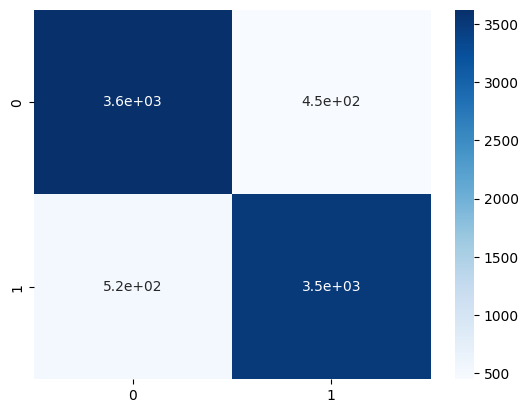

In [79]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

cm = confusion_matrix(y_pred=y_pred, y_true=y_test)
print(accuracy_score(y_pred=y_pred, y_true=y_test))
print(classification_report(y_pred=y_pred, y_true=y_test))
print(cm)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.show()

**88%** accuracy with similar `recall` and `precision`

In [ ]:
with open('model.pkl', 'wb') as f:
    pickle.dump(random_search, f)

print("Best model dumped to model.pkl")

with open('tf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tf, f)

print("TF-IDF vectorizer dumped to tf_vectorizer.pkl")

Best model dumped to model.pkl
TF-IDF vectorizer dumped to tf_vectorizer.pkl
